Dataset saved


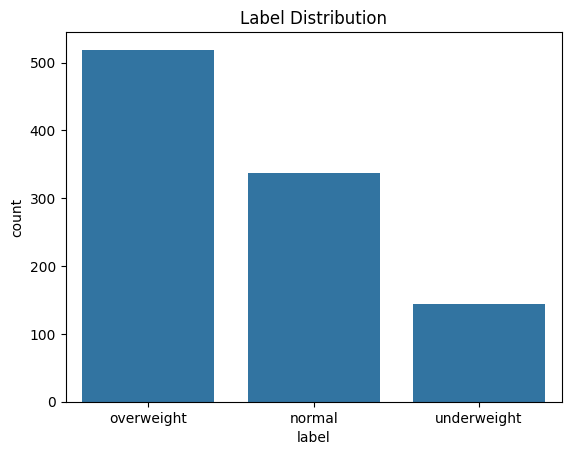

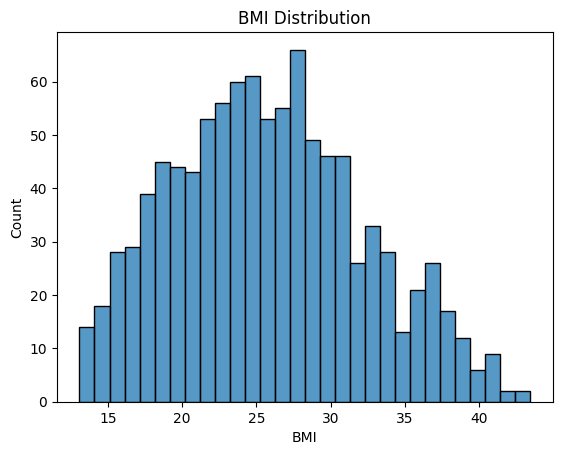

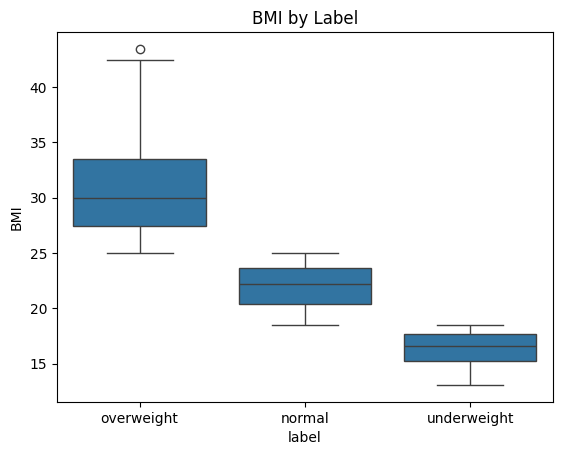

d:\Python\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3150 - loss: 1.1230
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5213 - loss: 1.0336
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5213 - loss: 1.0020
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5213 - loss: 0.9880
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5213 - loss: 0.9804
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5213 - loss: 0.9723
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5213 - loss: 0.9659
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5213 - loss: 0.9614
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5213 - loss: 0.9586
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5213 - loss: 0.9546
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


d:\Python\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


d:\Python\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
                    Accuracy    MAE    MSE      RMSE
LogisticRegression     0.985  0.020  0.030  0.173205
DecisionTree           0.945  0.070  0.100  0.316228
SVM                    0.945  0.070  0.100  0.316228
KNN                    0.905  0.130  0.200  0.447214
RandomForest           0.955  0.060  0.090  0.300000
CNN                    0.510  0.490  0.490  0.700000
RNN                    0.845  0.275  0.515  0.717635
LSTM                   0.945  0.065  0.085  0.291548


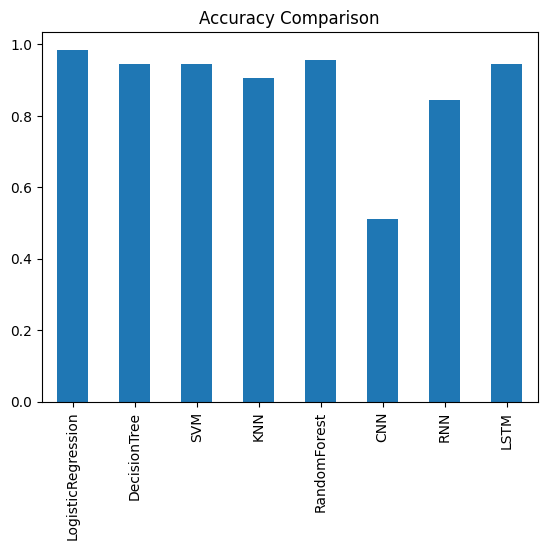

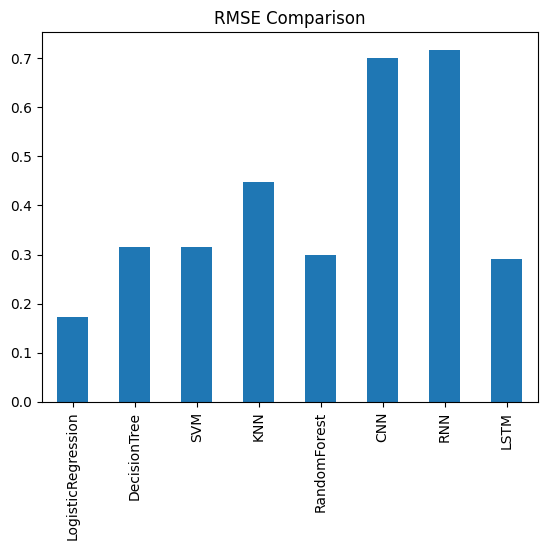

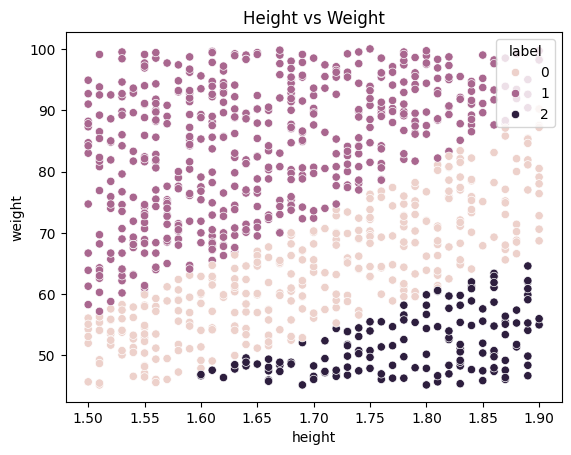

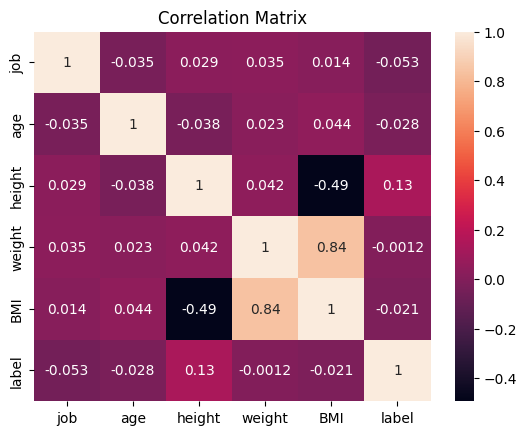

<Figure size 640x480 with 0 Axes>

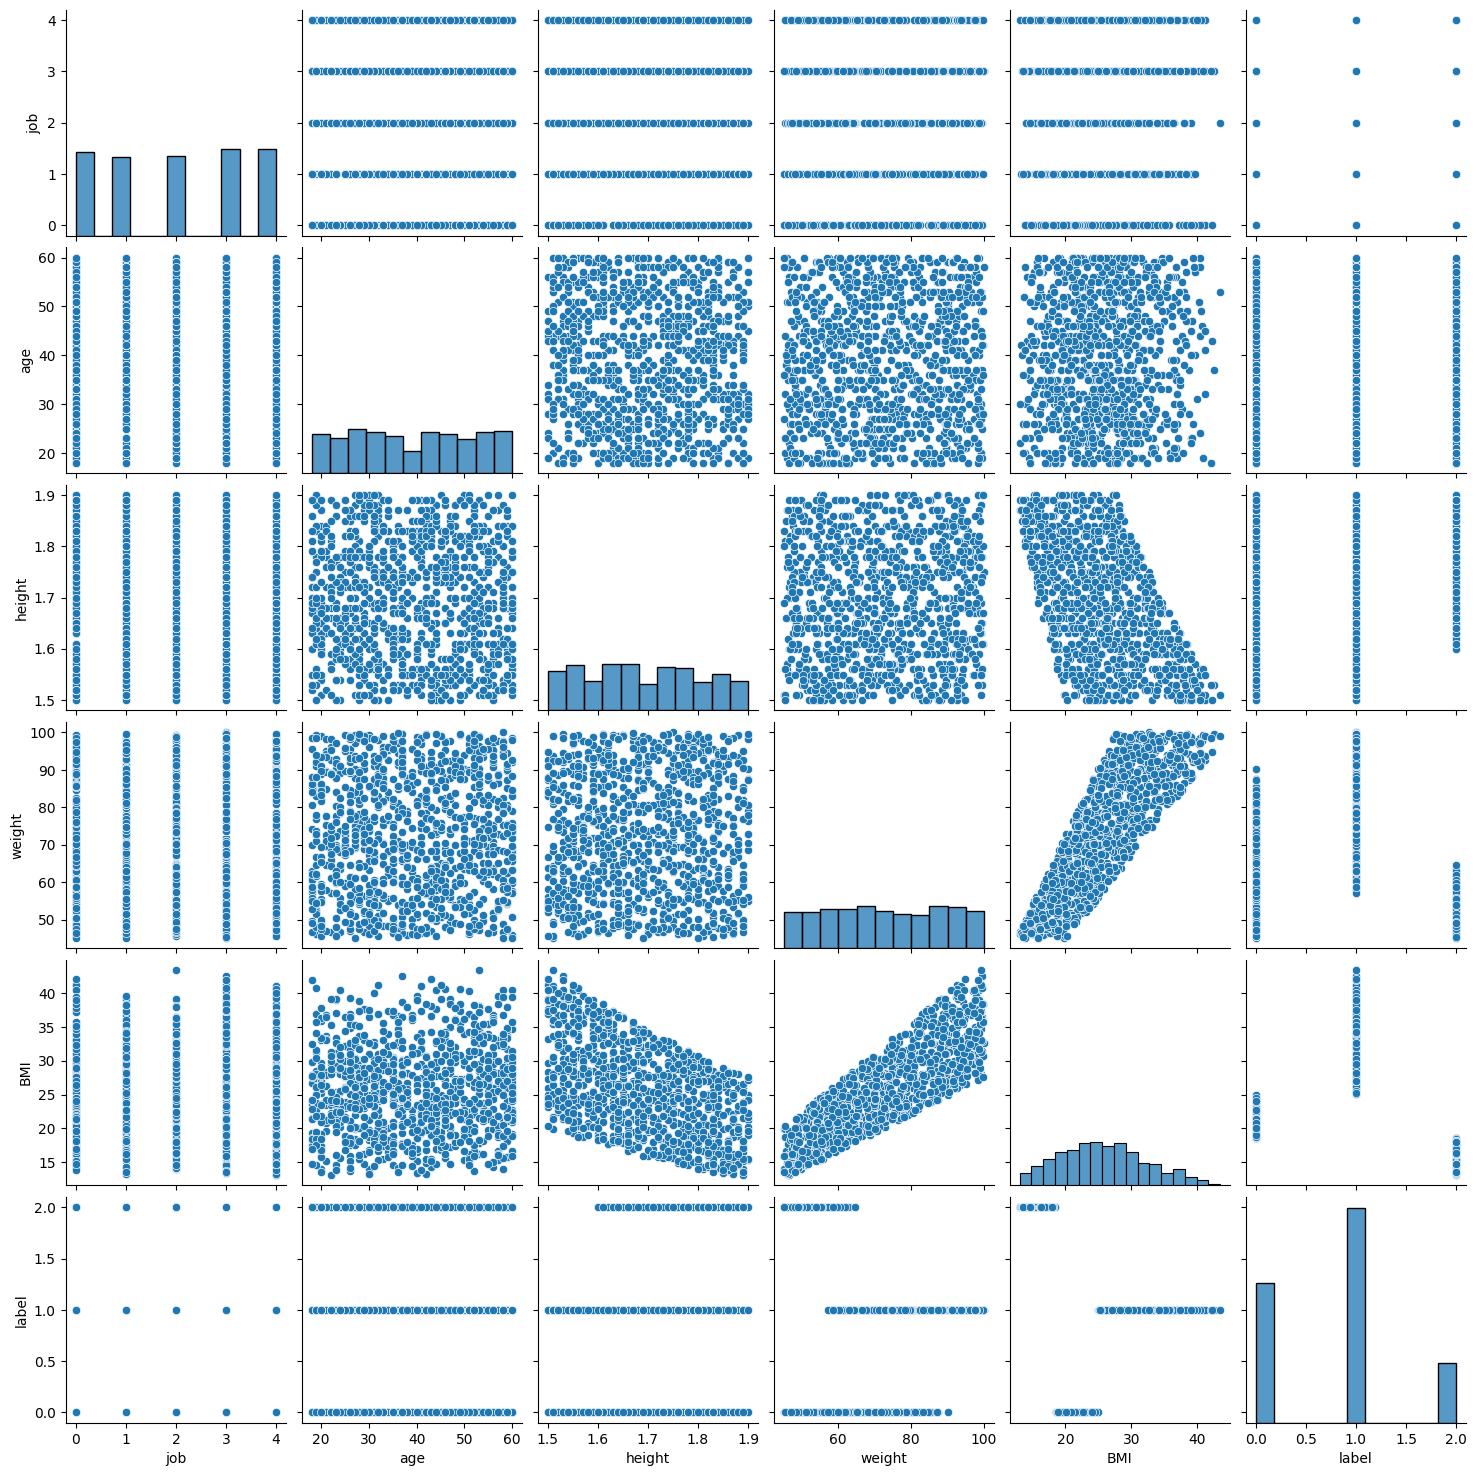

Best model: LogisticRegression
Result: overweight
Guide: Exercise regularly and reduce calories.


d:\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:
# ================================
# NAME: YOUR_NAME
# DL01 TENSORFLOW - KERAS
# ================================

import numpy as np
import pandas as pd
import random
import os
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score,mean_absolute_error,mean_squared_error

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv1D,MaxPooling1D,Flatten,SimpleRNN,LSTM

# =====================================
# a. BUILD DATASET
# =====================================

os.makedirs("C:/DATA",exist_ok=True)

jobs = ["student","teacher","doctor","engineer","worker"]

data=[]

for i in range(1000):

    job=random.choice(jobs)
    age=random.randint(18,60)
    height=round(random.uniform(1.5,1.9),2)
    weight=round(random.uniform(45,100),1)

    bmi=weight/(height**2)

    if bmi<18.5:
        label="underweight"
    elif bmi<25:
        label="normal"
    else:
        label="overweight"

    data.append([job,age,height,weight,bmi,label])

df=pd.DataFrame(data,columns=["job","age","height","weight","BMI","label"])

df.to_csv("C:/DATA/data_4.1.csv",index=False)

print("Dataset saved")

# =====================================
# b. DATA DISTRIBUTION (3 types)
# =====================================

plt.figure()
sns.countplot(x="label",data=df)
plt.title("Label Distribution")
plt.show()

plt.figure()
sns.histplot(df["BMI"],bins=30)
plt.title("BMI Distribution")
plt.show()

plt.figure()
sns.boxplot(x="label",y="BMI",data=df)
plt.title("BMI by Label")
plt.show()

# =====================================
# ENCODE DATA
# =====================================

job_encoder=LabelEncoder()
label_encoder=LabelEncoder()

df["job"]=job_encoder.fit_transform(df["job"])
df["label"]=label_encoder.fit_transform(df["label"])

X=df[["job","age","height","weight"]]
y=df["label"]

scaler=StandardScaler()
X=scaler.fit_transform(X)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# =====================================
# c. 5 BASIC ML MODELS
# =====================================

models={

"LogisticRegression":LogisticRegression(),
"DecisionTree":DecisionTreeClassifier(),
"SVM":SVC(),
"KNN":KNeighborsClassifier(),
"RandomForest":RandomForestClassifier()

}

results={}

for name,model in models.items():

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    acc=accuracy_score(y_test,pred)
    mae=mean_absolute_error(y_test,pred)
    mse=mean_squared_error(y_test,pred)
    rmse=np.sqrt(mse)

    results[name]=[acc,mae,mse,rmse]

# =====================================
# d. CNN RNN LSTM (5 layers)
# =====================================

# reshape cho deep learning
# reshape cho deep learning
X_train_dl = X_train.reshape(X_train.shape[0], 4, 1)
X_test_dl = X_test.reshape(X_test.shape[0], 4, 1)

y_train = np.array(y_train).reshape(-1)
y_test = np.array(y_test).reshape(-1)

cnn = Sequential([
    Conv1D(32, 2, activation='relu', input_shape=(4,1)),
    MaxPooling1D(pool_size=2),
    Conv1D(16, 1, activation='relu'),
    Flatten(),
    Dense(3, activation='softmax')
])

cnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

cnn.fit(X_train_dl, y_train, epochs=10, verbose=1)

pred = np.argmax(cnn.predict(X_test_dl), axis=1)

results["CNN"]=[
accuracy_score(y_test,pred),
mean_absolute_error(y_test,pred),
mean_squared_error(y_test,pred),
np.sqrt(mean_squared_error(y_test,pred))
]

# RNN
rnn=Sequential([
SimpleRNN(32,input_shape=(4,1)),
Dense(16,activation='relu'),
Dense(8,activation='relu'),
Dense(4,activation='relu'),
Dense(3,activation='softmax')
])

rnn.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
rnn.fit(X_train_dl,y_train,epochs=10,verbose=0)

pred=np.argmax(rnn.predict(X_test_dl),axis=1)

results["RNN"]=[
accuracy_score(y_test,pred),
mean_absolute_error(y_test,pred),
mean_squared_error(y_test,pred),
np.sqrt(mean_squared_error(y_test,pred))
]

# LSTM
lstm=Sequential([
LSTM(32,input_shape=(4,1)),
Dense(16,activation='relu'),
Dense(8,activation='relu'),
Dense(4,activation='relu'),
Dense(3,activation='softmax')
])

lstm.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
lstm.fit(X_train_dl,y_train,epochs=10,verbose=0)

pred=np.argmax(lstm.predict(X_test_dl),axis=1)

results["LSTM"]=[
accuracy_score(y_test,pred),
mean_absolute_error(y_test,pred),
mean_squared_error(y_test,pred),
np.sqrt(mean_squared_error(y_test,pred))
]

# =====================================
# e. COMPARE MODELS
# =====================================

results_df=pd.DataFrame(results,index=["Accuracy","MAE","MSE","RMSE"]).T

print(results_df)

# =====================================
# f. VISUALIZATION >=5
# =====================================

plt.figure()
results_df["Accuracy"].plot(kind="bar")
plt.title("Accuracy Comparison")
plt.show()

plt.figure()
results_df["RMSE"].plot(kind="bar")
plt.title("RMSE Comparison")
plt.show()

plt.figure()
sns.scatterplot(x=df["height"],y=df["weight"],hue=df["label"])
plt.title("Height vs Weight")
plt.show()

plt.figure()
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation Matrix")
plt.show()

plt.figure()
sns.pairplot(df)
plt.show()

# =====================================
# g. DEPLOY MODEL + HEALTH GUIDE
# =====================================

health_guide={

"underweight":"Eat more nutritious food and exercise.",
"normal":"Maintain healthy lifestyle.",
"overweight":"Exercise regularly and reduce calories."

}

with open("C:/DATA/kb_healthGuide.json","w") as f:
    json.dump(health_guide,f)

best_model_name=results_df["Accuracy"].idxmax()

print("Best model:",best_model_name)

best_model=models.get(best_model_name,None)
joblib.dump(best_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(job_encoder, "job_encoder.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

def predict_person(job,age,height,weight):

    job=job_encoder.transform([job])[0]

    X=np.array([[job,age,height,weight]])
    X=scaler.transform(X)

    pred=best_model.predict(X)

    label=label_encoder.inverse_transform(pred)[0]

    guide=health_guide[label]

    print("Result:",label)
    print("Guide:",guide)

predict_person("engineer",30,1.7,80)